In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import seaborn as sns
#Data Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Modeling
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor


# Evaluation
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error,root_mean_squared_error


In [4]:
df=pd.read_csv("C:/Users/priya/OneDrive/Desktop/datascience/content/youtube_ad_revenue_dataset.csv")
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [5]:
df.shape

(122400, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [7]:
df.columns

Index(['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd'],
      dtype='object')

In [8]:
df.isna().sum()

video_id                   0
date                       0
views                      0
likes                   6117
comments                6112
watch_time_minutes      6105
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [9]:
df['likes'].skew()

np.float64(-0.0027579035972128923)

In [10]:
df['likes'] = df['likes'].fillna(df['likes'].mean())

In [11]:
df['likes'].isna().sum()

np.int64(0)

In [12]:
df['comments'].skew()

np.float64(0.007735157212128024)

<Axes: ylabel='Frequency'>

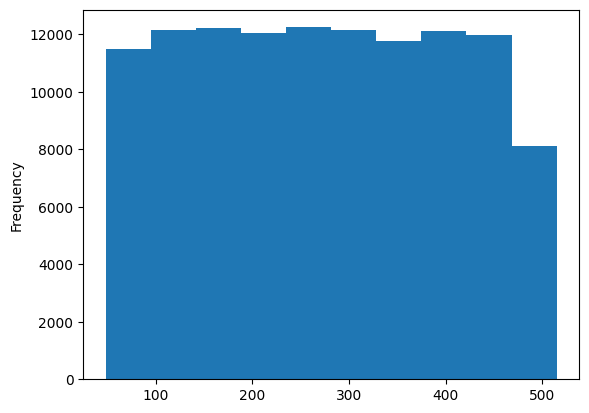

In [13]:
df['comments'].plot(kind="hist")

In [14]:
df['comments'] = df['comments'].fillna(df['comments'].mean())

In [15]:
df['comments'].isna().sum()

np.int64(0)

In [16]:
df['watch_time_minutes'].skew()

np.float64(0.0009027191329527335)

In [17]:
df['watch_time_minutes'] = df['watch_time_minutes'].fillna(df['watch_time_minutes'].mean())

In [18]:
df['watch_time_minutes'].isna().sum()

np.int64(0)

In [19]:
df['engagement_rate'] = (df['likes'] + df['comments']) / df['views']


In [20]:
df.duplicated().sum()

np.int64(2400)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.dtypes

video_id                 object
date                     object
views                     int64
likes                   float64
comments                float64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                 object
device                   object
country                  object
ad_revenue_usd          float64
engagement_rate         float64
dtype: object

In [24]:
df.columns

Index(['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd', 'engagement_rate'],
      dtype='object')

In [25]:
df.drop(['video_id','date'], axis=1, inplace=True)

In [26]:
df.isna().sum()

views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
engagement_rate         0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.to_csv("cleaned_dataset.csv", index=False)


print("Cleaned dataset saved as 'cleaned_dataset.csv'")


Cleaned dataset saved as 'cleaned_dataset.csv'


In [29]:
X=df.drop(['ad_revenue_usd','device','country','category'],axis=1)
Y=df['ad_revenue_usd']

In [30]:
Num_Disc=X.select_dtypes(include=['int64'])
Num_Cont=X.select_dtypes(include=['float64'])



In [31]:
numeric_features = list(Num_Cont.columns) + list(Num_Disc.columns)

In [32]:
numeric_features 

['likes',
 'comments',
 'watch_time_minutes',
 'video_length_minutes',
 'engagement_rate',
 'views',
 'subscribers']

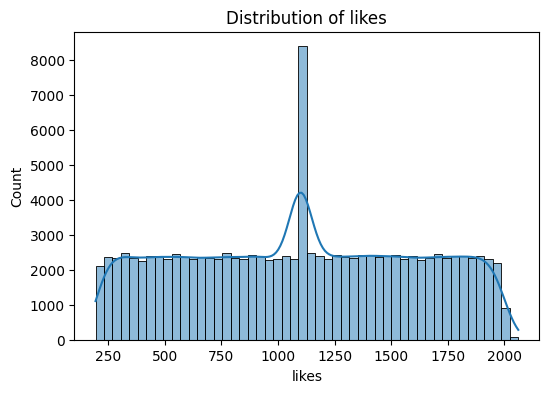

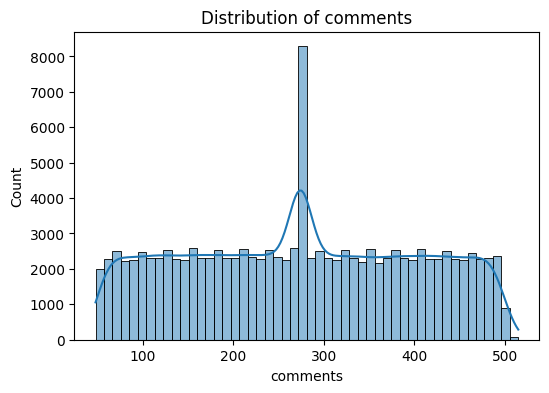

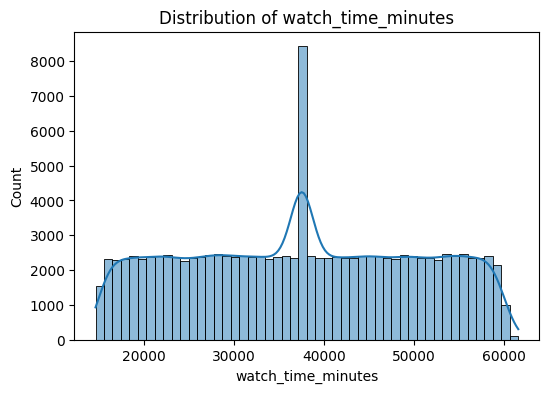

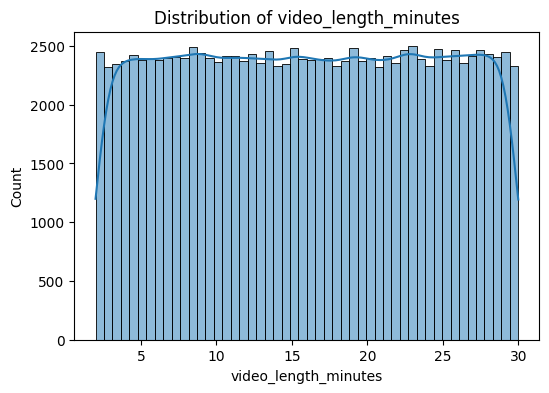

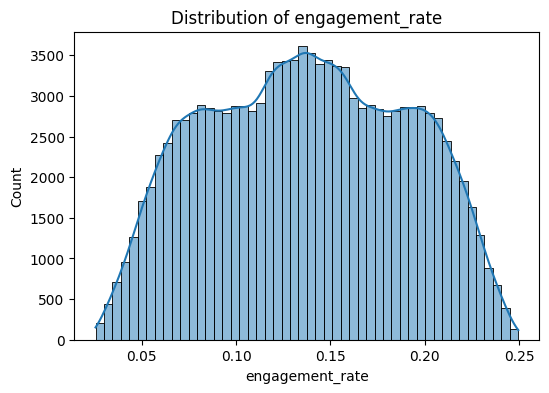

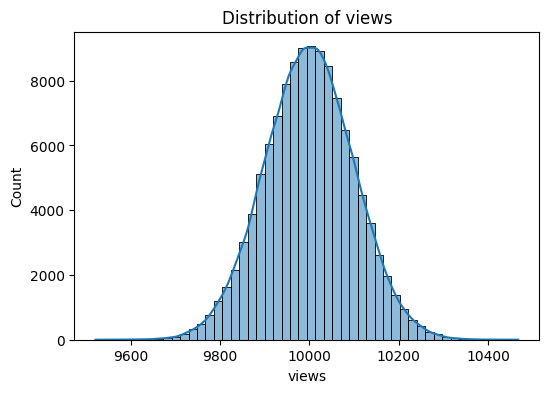

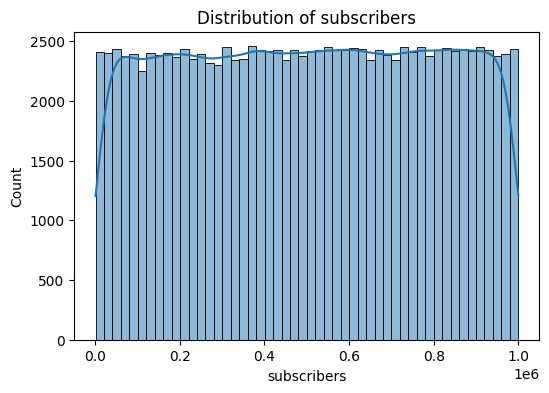

In [33]:
# Histograms
for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()



In [34]:
import numpy as np

Q1 = np.percentile(df['ad_revenue_usd'], 25)
Q3 = np.percentile(df['ad_revenue_usd'], 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['ad_revenue_usd'] < lower_bound) | (df['ad_revenue_usd'] > upper_bound)]
print("Outlier count:", len(outliers))


Outlier count: 0


In [ ]:
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),])


In [36]:
Num_Cont.columns

Index(['likes', 'comments', 'watch_time_minutes', 'video_length_minutes',
       'engagement_rate'],
      dtype='object')

In [37]:
Num_Disc.columns

Index(['views', 'subscribers'], dtype='object')

In [38]:
#############LinearRegression##############

In [39]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((96000, 7), (24000, 7), (96000,), (24000,))

In [40]:
model1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Fit pipeline
model1.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [41]:

Y_pred = model1.predict(X_test)

In [42]:
Y_train_pred = model1.predict(X_train)
Y_test_pred = model1.predict(X_test)

In [43]:
# MAE For Train and Test
MAE_train=mean_absolute_error(Y_train,Y_train_pred)
MAE_test=mean_absolute_error(Y_test,Y_test_pred)
print('Train MAE:',MAE_train, 'in Mins')
print('Test MAE:',MAE_test,'in Mins')
# MSE For Train and Test
MSE_train=mean_squared_error(Y_train,Y_train_pred)
MSE_test=mean_squared_error(Y_test,Y_test_pred)
print('Train MSE:',MSE_train,'in Mins')
print('Test MSE:',MSE_test,'in Mins')
# RMSE For Train and Test
RMSE_train=np.sqrt(MSE_train)
RMSE_test=np.sqrt(MSE_test)
print('Train RMSE:',RMSE_train,'in Mins')
print('Test RMSE:',RMSE_test,'in Mins')

# R2 Score For Train and Test
R2_train=r2_score(Y_train,Y_train_pred)
R2_test=r2_score(Y_test,Y_test_pred)
print('Train R2 Score:',R2_train)
print('Test R2 Score:',R2_test)

Train MAE: 3.23609153912446 in Mins
Test MAE: 3.083082799521635 in Mins
Train MSE: 193.1325724410966 in Mins
Test MSE: 181.67471438800501 in Mins
Train RMSE: 13.897214556920988 in Mins
Test RMSE: 13.478676284710046 in Mins
Train R2 Score: 0.9497048357497174
Test R2 Score: 0.9525836125435825


In [44]:
help(DecisionTreeRegressor)

Help on class DecisionTreeRegressor in module sklearn.tree._classes:

class DecisionTreeRegressor(sklearn.base.RegressorMixin, BaseDecisionTree)
 |  DecisionTreeRegressor(*, criterion='squared_error', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, ccp_alpha=0.0, monotonic_cst=None)
 |
 |  A decision tree regressor.
 |
 |  Read more in the :ref:`User Guide <tree>`.
 |
 |  Parameters
 |  ----------
 |  criterion : {"squared_error", "friedman_mse", "absolute_error",             "poisson"}, default="squared_error"
 |      The function to measure the quality of a split. Supported criteria
 |      are "squared_error" for the mean squared error, which is equal to
 |      variance reduction as feature selection criterion and minimizes the L2
 |      loss using the mean of each terminal node, "friedman_mse", which uses
 |      mean squared error with Fri

In [51]:
#####################DecisionTreeRegressor

In [45]:
from sklearn.tree import DecisionTreeRegressor
model2= Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(max_depth=3, random_state=42))
])
model2.fit(X_train, Y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [46]:
Y_pred =model2.predict(X_test)


In [47]:


MAE_train = mean_absolute_error(Y_train, Y_train_pred)
MAE_test = mean_absolute_error(Y_test, Y_test_pred)
print('Train MAE:', MAE_train, 'in Mins')
print('Test MAE:', MAE_test, 'in Mins')

# RMSE For Train and Test
MSE_train = mean_squared_error(Y_train, Y_train_pred)
MSE_test = mean_squared_error(Y_test, Y_test_pred)
RMSE_train = np.sqrt(MSE_train)
RMSE_test = np.sqrt(MSE_test)
print('Train RMSE:', RMSE_train, 'in Mins')
print('Test RMSE:', RMSE_test, 'in Mins')

# R2 Score For Train and Test
R2_train = r2_score(Y_train, Y_train_pred)
R2_test = r2_score(Y_test, Y_test_pred)
print('Train R2 Score:', R2_train)
print('Test R2 Score:', R2_test)



Train MAE: 3.23609153912446 in Mins
Test MAE: 3.083082799521635 in Mins
Train RMSE: 13.897214556920988 in Mins
Test RMSE: 13.478676284710046 in Mins
Train R2 Score: 0.9497048357497174
Test R2 Score: 0.9525836125435825


In [52]:
###########RandomForestRegressor

In [48]:
rf_reg = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", RandomForestRegressor( n_estimators=100,   # number of trees
        max_depth=None,     # let trees grow fully
        random_state=42 ))])


rf_reg.fit(X_train, Y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [49]:
Y_train_pred = rf_reg.predict(X_train)
Y_test_pred  = rf_reg.predict(X_test)


In [52]:
MAE_train = mean_absolute_error(Y_train, Y_train_pred)
MAE_test = mean_absolute_error(Y_test, Y_test_pred)
print('Train MAE:', MAE_train, 'in Mins')
print('Test MAE:', MAE_test, 'in Mins')

# RMSE
MSE_train = mean_squared_error(Y_train, Y_train_pred)
MSE_test = mean_squared_error(Y_test, Y_test_pred)
RMSE_train = np.sqrt(MSE_train)
RMSE_test = np.sqrt(MSE_test)
print('Train RMSE:', RMSE_train, 'in Mins')
print('Test RMSE:', RMSE_test, 'in Mins')

# R²
R2_train = r2_score(Y_train, Y_train_pred)
R2_test = r2_score(Y_test, Y_test_pred)
print('Train R2 Score:', R2_train)
print('Test R2 Score:', R2_test)


Train MAE: 1.4201398321323784 in Mins
Test MAE: 3.6010313660772297 in Mins
Train RMSE: 5.382803578586998 in Mins
Test RMSE: 13.911564157507573 in Mins
Train R2 Score: 0.9924545043936243
Test R2 Score: 0.9494890074148347


In [50]:
###########KNeighborsRegressor###############

In [52]:
knn_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", KNeighborsRegressor(
        n_neighbors=6,     
        weights="uniform" ))])

knn_reg.fit(X_train, Y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [53]:
Y_train_pred = knn_reg.predict(X_train)
Y_test_pred  = knn_reg.predict(X_test)


In [54]:
MAE_train = mean_absolute_error(Y_train, Y_train_pred)
MAE_test = mean_absolute_error(Y_test, Y_test_pred)

MSE_train = mean_squared_error(Y_train, Y_train_pred)
MSE_test = mean_squared_error(Y_test, Y_test_pred)
R2_train = r2_score(Y_train, Y_train_pred)
R2_test = r2_score(Y_test, Y_test_pred)

print('Train MAE:', MAE_train, 'in Mins')
print('Test MAE:', MAE_test, 'in Mins')
print('Train MSE:', MSE_train)
print('Test MSE:', MSE_test)
print('Train R2 Score:', R2_train)
print('Test R2 Score:', R2_test)


Train MAE: 7.463249312908033 in Mins
Test MAE: 8.66131789767271 in Mins
Train MSE: 191.8784694968256
Test MSE: 262.63937660599976
Train R2 Score: 0.9500314265094822
Test R2 Score: 0.9314521534578272


In [55]:
###########Lasso Regresion###########

In [56]:

lasso_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Lasso(alpha=0.1, random_state=42))  # alpha controls regularization strength
])
lasso_reg.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [57]:
Y_train_pred = lasso_reg.predict(X_train)
Y_test_pred  = lasso_reg.predict(X_test)

In [58]:
MAE_train = mean_absolute_error(Y_train, Y_train_pred)
MAE_test = mean_absolute_error(Y_test, Y_test_pred)

MSE_train = mean_squared_error(Y_train, Y_train_pred)
MSE_test = mean_squared_error(Y_test, Y_test_pred)
R2_train = r2_score(Y_train, Y_train_pred)
R2_test = r2_score(Y_test, Y_test_pred)

print('Train MAE:', MAE_train, 'in Mins')
print('Test MAE:', MAE_test, 'in Mins')
print('Train MSE:', MSE_train)
print('Test MSE:', MSE_test)
print('Train R2 Score:', R2_train)
print('Test R2 Score:', R2_test)

Train MAE: 3.2758914208584216 in Mins
Test MAE: 3.1224754775447168 in Mins
Train MSE: 193.18714501395038
Test MSE: 181.64991768523927
Train R2 Score: 0.9496906240790471
Test R2 Score: 0.9525900843856875


In [59]:
from sklearn.linear_model import Ridge

ridge_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0, random_state=42))  # alpha controls regularization strength
])

ridge_reg.fit(X_train, Y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [60]:
Y_train_pred = ridge_reg .predict(X_train)
Y_test_pred  = ridge_reg .predict(X_test)

In [61]:
MAE_train = mean_absolute_error(Y_train, Y_train_pred)
MAE_test = mean_absolute_error(Y_test, Y_test_pred)

MSE_train = mean_squared_error(Y_train, Y_train_pred)
MSE_test = mean_squared_error(Y_test, Y_test_pred)
R2_train = r2_score(Y_train, Y_train_pred)
R2_test = r2_score(Y_test, Y_test_pred)

print('Train MAE:', MAE_train, 'in Mins')
print('Test MAE:', MAE_test, 'in Mins')
print('Train MSE:', MSE_train)
print('Test MSE:', MSE_test)
print('Train R2 Score:', R2_train)
print('Test R2 Score:', R2_test)

Train MAE: 3.23417124046922 in Mins
Test MAE: 3.0811936231480748 in Mins
Train MSE: 193.1329327485242
Test MSE: 181.66697210571422
Train R2 Score: 0.9497047419192411
Test R2 Score: 0.9525856332488751


In [62]:
import pickle # Save pipeline
with open("RandomForestRegressor_model.pkl", "wb") as f:  #####certainly good model
    pickle.dump(rf_reg, f)

print("model saved successfully!")

model saved successfully!


In [62]:
with open("RandomForestRegressor_model.pkl", "wb") as f:
    pickle.dump(rf_reg, f)

In [63]:
Y_pred = rf_reg.predict(X_test)
print("Predictions:", Y_pred)

Predictions: [352.92510273 342.07537763 204.46000907 ... 171.06606592 261.32014672
 285.38520049]
